# Modèle XGBoost — Fraud Detection

In [1]:
import pandas as pd
import numpy as np
import boto3
import os
import psycopg2
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient
from mlflow.utils.rest_utils import http_request
import mlflow.xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, average_precision_score

### Chargement et feature engineering

In [2]:
df = pd.read_csv('../01_Data/fraudTest.csv', index_col=0)

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour']         = df['trans_date_trans_time'].dt.hour
df['geo_distance'] = np.sqrt(
    (df['lat'] - df['merch_lat']) ** 2 +
    (df['long'] - df['merch_long']) ** 2
)

df = pd.get_dummies(df, columns=['category'], drop_first=False)

FEATURE_COLS = (
    ['amt', 'city_pop', 'geo_distance', 'hour']
    + [c for c in df.columns if c.startswith('category_')]
)

X = df[FEATURE_COLS]
y = df['is_fraud']

print('Features :', FEATURE_COLS)
print('Shape X  :', X.shape)
print('Fraudes  :', y.sum(), '/', len(y))

Features : ['amt', 'city_pop', 'geo_distance', 'hour', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']
Shape X  : (555719, 18)
Fraudes  : 2145 / 555719


### Split train / test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train :', X_train.shape, '| Test :', X_test.shape)
print('Taux fraude train :', round(y_train.mean(), 4))
print('Taux fraude test  :', round(y_test.mean(), 4))

Train : (444575, 18) | Test : (111144, 18)
Taux fraude train : 0.0039
Taux fraude test  : 0.0039


### Entraînement XGBoost

In [ ]:
# Compenser le déséquilibre de classes
scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())
print('scale_pos_weight :', scale_pos_weight)

params = {
    'n_estimators':      200, #Nombre d'arbres construits séquentiellement
    'max_depth':         6, #Profondeur max de chaque arbre — contrôle la complexité
    'learning_rate':     0.1,#Pas d'apprentissage — plus petit = plus robuste mais plus lent
    'subsample':         0.8,#80% des lignes tirées aléatoirement par arbre — réduit l'overfitting
    'colsample_bytree':  0.8,#80% des features tirées aléatoirement par arbre — réduit l'overfitting
    'scale_pos_weight':  scale_pos_weight,#Compense le déséquilibre de classes en donnant plus de poids aux fraudes
    'random_state':      42,
    'eval_metric':       'aucpr',#Métrique d'évaluation = aire sous la courbe Précision/Rappel
    'use_label_encoder': False,
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)
print('Entraînement terminé')

scale_pos_weight : 258


/opt/anaconda3/envs/ml/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Entraînement terminé


### Évaluation

In [5]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Légitime', 'Fraude']))

ROC-AUC : 0.9969
PR-AUC  : 0.8179

              precision    recall  f1-score   support

    Légitime       1.00      0.99      1.00    110715
      Fraude       0.32      0.93      0.47       429

    accuracy                           0.99    111144
   macro avg       0.66      0.96      0.73    111144
weighted avg       1.00      0.99      0.99    111144



ROC-AUC0.9969 —> le modèle distingue quasi-parfaitement les deux classes
PR-AUC0.8179 —> bien au-dessus du hasard (≈ 0.4% de fraudes)

precision: 0,32: 
Recall 0.93 → le modèle détecte 93% des vraies fraudes (399/429)
Precision 0.32 → parmi toutes les alertes fraude, seulement 32% sont de vraies fraudes — les 68% restantes sont des faux positifs (transactions légitimes bloquées à tort)

En chiffres : pour 429 fraudes détectées, le modèle génère environ ~900 fausses alarmes.

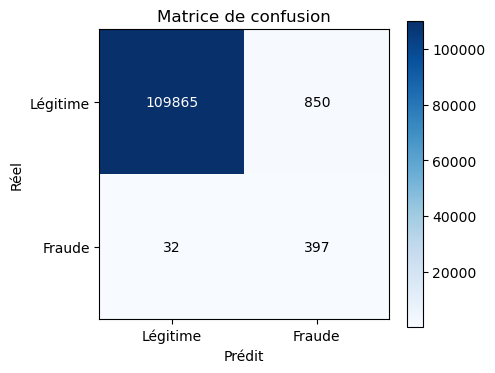

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Légitime', 'Fraude'])
ax.set_yticklabels(['Légitime', 'Fraude'])
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

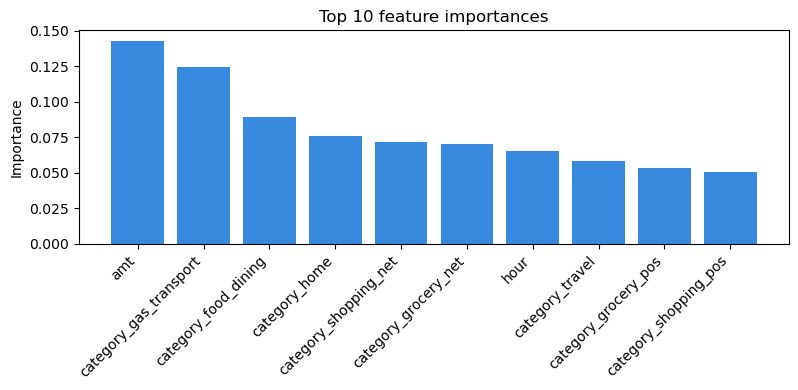

In [7]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(top10.index, top10.values, color='#378ADD')
ax.set_title('Top 10 feature importances')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Log MLflow + enregistrement du modèle

In [8]:
# Variables S3/MinIO
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://localhost:9000'
os.environ['AWS_ACCESS_KEY_ID']       = 'minioadmin'
os.environ['AWS_SECRET_ACCESS_KEY']   = 'minioadmin'

MLFLOW_TRACKING_URI = 'http://localhost:5001'
EXPERIMENT_NAME     = 'fraud-detection'

In [9]:
s3 = boto3.client('s3',
    endpoint_url='http://localhost:9000',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin'
)
try:
    s3.create_bucket(Bucket='mlflow-artifacts')
    print("Bucket créé")
except s3.exceptions.BucketAlreadyOwnedByYou:
    print("Bucket existe déjà")

Bucket existe déjà


In [15]:
report = classification_report(y_test, y_pred, output_dict=True)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()

# Supprimer toutes les expériences existantes avec ce nom
for exp in client.search_experiments(filter_string=f"name = '{EXPERIMENT_NAME}'"):
    client.delete_experiment(exp.experiment_id)

# Recréer avec artifact location via MLflow HTTP proxy
client.create_experiment(
    name=EXPERIMENT_NAME,
    artifact_location='s3://mlflow-artifacts'
)

mlflow.set_experiment(EXPERIMENT_NAME)
print('Expérience créée | artifact_location=mlflow-artifacts:/fraud-detection')

with mlflow.start_run(run_name='xgboost-baseline'):

    mlflow.log_params(params)
    mlflow.log_metrics({
        'roc_auc':   roc_auc,
        'pr_auc':    pr_auc,
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
    })

    mlflow.xgboost.log_model(
        model,
        artifact_path='fraud-detector',
        registered_model_name='fraud-detector',
        input_example=X_test.iloc[:1],
    )

    latest = client.get_latest_versions('fraud-detector')[-1]
    client.transition_model_version_stage(
        name='fraud-detector',
        version=latest.version,
        stage='Production'
    )

    print(f'Modèle v{latest.version} enregistré et promu en Production')

Expérience créée | artifact_location=mlflow-artifacts:/fraud-detection


/opt/anaconda3/envs/ml/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing

Modèle v1 enregistré et promu en Production
🏃 View run xgboost-baseline at: http://localhost:5001/#/experiments/108/runs/d015ced470e44a47aee708e47bf7cdcf
🧪 View experiment at: http://localhost:5001/#/experiments/108


Created version '1' of model 'fraud-detector'.
/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_3991/99898110.py:37: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest = client.get_latest_versions('fraud-detector')[-1]
/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_3991/99898110.py:38: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [20]:
#### Forcer fraude pour tester email
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime
from dotenv import load_dotenv

load_dotenv()

SMTP_USER     = os.getenv("SMTP_USER")
SMTP_PASSWORD = os.getenv("SMTP_PASSWORD")
ALERT_TO      = os.getenv("ALERT_TO")

transaction = {
    "trans_num": "TEST-FRAUDE-001",
    "amt": 999.99,
    "merchant": "fraud_Test_Merchant",
    "city": "Paris",
    "state": "FR"
}
score = 0.9823

subject = f"[ALERTE FRAUDE] Transaction {transaction['trans_num']}"
body = f"""
Une transaction suspecte a été détectée.

Transaction : {transaction['trans_num']}
Montant     : ${transaction['amt']}
Marchand    : {transaction['merchant']}
Lieu        : {transaction['city']}, {transaction['state']}
Score fraude: {score:.4f}
Heure       : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

msg = MIMEMultipart()
msg["From"]    = SMTP_USER
msg["To"]      = ALERT_TO
msg["Subject"] = subject
msg.attach(MIMEText(body, "plain"))

with smtplib.SMTP("smtp.gmail.com", 587) as server:
    server.starttls()
    server.login(SMTP_USER, SMTP_PASSWORD)
    server.sendmail(SMTP_USER, ALERT_TO, msg.as_string())

print("Email envoyé !")

Email envoyé !


In [14]:
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    dbname="mlflow_db",
    user="fraud_user",
    password="fraud_pass"
)
cur = conn.cursor()

# Récupérer l'experiment_id
cur.execute("SELECT experiment_id FROM experiments WHERE name = 'fraud-detection';")
exp_id = cur.fetchone()[0]
print(f"experiment_id : {exp_id}")

# Supprimer dans l'ordre des dépendances
cur.execute("DELETE FROM tags WHERE run_uuid IN (SELECT run_uuid FROM runs WHERE experiment_id = %s);", (exp_id,))
cur.execute("DELETE FROM params WHERE run_uuid IN (SELECT run_uuid FROM runs WHERE experiment_id = %s);", (exp_id,))
cur.execute("DELETE FROM metrics WHERE run_uuid IN (SELECT run_uuid FROM runs WHERE experiment_id = %s);", (exp_id,))
cur.execute("DELETE FROM latest_metrics WHERE run_uuid IN (SELECT run_uuid FROM runs WHERE experiment_id = %s);", (exp_id,))
cur.execute("DELETE FROM model_versions WHERE run_id IN (SELECT run_uuid FROM runs WHERE experiment_id = %s);", (exp_id,))
cur.execute("DELETE FROM runs WHERE experiment_id = %s;", (exp_id,))
cur.execute("DELETE FROM experiments WHERE experiment_id = %s;", (exp_id,))

conn.commit()
cur.close()
conn.close()
print("Expérience et runs supprimés proprement")

experiment_id : 105
Expérience et runs supprimés proprement


In [11]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

client = MlflowClient()

# Supprimer l'ancienne expérience si elle existe avec le mauvais artifact root
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is not None:
    client.delete_experiment(experiment.experiment_id)

# Recréer avec le bon artifact root
client.create_experiment(
    name=EXPERIMENT_NAME,
    artifact_location='s3://mlflow-artifacts'
)
mlflow.set_experiment(EXPERIMENT_NAME)
print('MLflow connecté :', MLFLOW_TRACKING_URI)

MLflow connecté : http://localhost:5001
